In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Generate the data

In [4]:
np.random.seed(42)

m = 100 #training examples
n = 2 #features

# Define the parameters we want the model to recover
phi = 0.5
mu_0 = np.array([[-0.5],[0]])
mu_1 = np.array([[1.5], [1]])
Sigma = np.array([[1, -0.5], 
                  [-0.5, 1.5]])

y = (phi > np.random.rand(m, 1)).astype(int).reshape((m,1))

X = np.zeros((m, n))
for i, y_i in enumerate(y):
    if y[i, 0] == 0:
        X[i] = np.random.multivariate_normal(
            mean = mu_0.flatten(),
            cov = Sigma
        )
    else:
        X[i] = np.random.multivariate_normal(
            mean = mu_1.flatten(),
            cov = Sigma
        )

## Plot the data

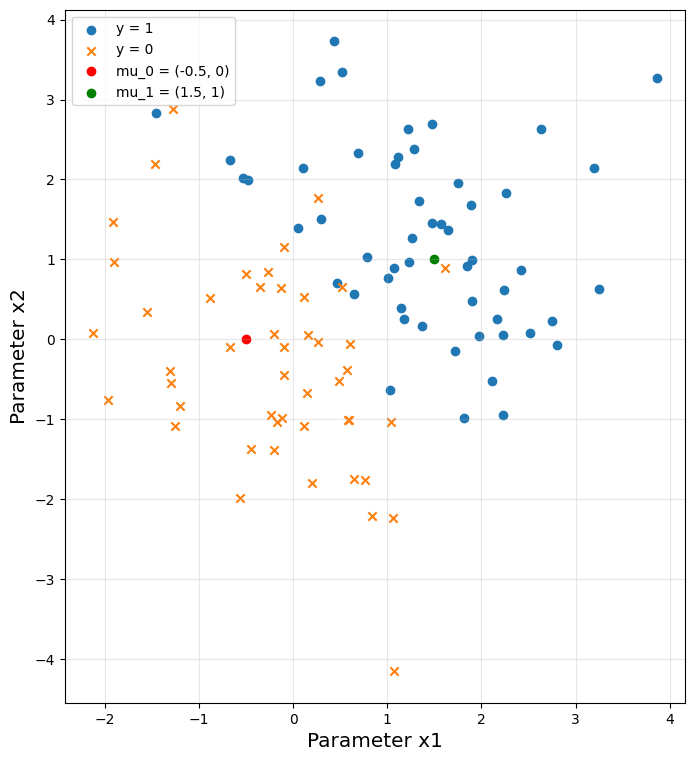

In [22]:
plt.figure(figsize = (8, 9))
ones = y[:, 0] == 1
zeros = y[:, 0] == 0

plt.scatter(X[ones, 0], X[ones, 1], marker = 'o', label = 'y = 1')
plt.scatter(X[zeros, 0], X[zeros, 1], marker = 'x', label = 'y = 0')

plt.scatter(-0.5, 0, color = 'red', label = 'mu_0 = (-0.5, 0)')
plt.scatter(1.5, 1, color = 'green', label = 'mu_1 = (1.5, 1)')

plt.xlabel('Parameter x1', fontsize = 'x-large')
plt.ylabel('Parameter x2', fontsize = 'x-large')
plt.legend()
plt.grid(alpha = 0.3)

plt.show()

## Create the GDA model

We will fit the parameters by maximizing the Joint Likelihood.

In [6]:
phi_est = np.mean(y)
mu0_est = np.mean(X[y.flatten() == 0], axis = 0)
mu1_est = np.mean(X[y.flatten() == 1], axis = 0)

Sigma_est = np.zeros((n, n))
for i in range(m):
    if y[i] == 0:
        mu = mu0_est
    else:
        mu = mu1_est
        
    diff = (X[i] - mu).reshape(n, 1)
    Sigma_est += (diff @ diff.T)

Sigma_est /= m

In [23]:
def gaussian_pdf(X, mu, Sigma):
    Sigma_det = np.linalg.det(Sigma)
    Sigma_inv = np.linalg.inv(Sigma)
    diff = X - mu.flatten()
    return 1 / ((2 * np.pi) ** (n/2) * Sigma_det ** (1/2)) * np.exp(-0.5 * np.sum(diff @ Sigma_inv * diff, axis = 1))

def calc_Px(Px_y0, Px_y1, phi_est):
    # Bayes rule
    return Px_y1 * phi_est + Px_y0 * (1 - phi_est)

In [24]:
Px_y0 = gaussian_pdf(X, mu0_est, Sigma_est)
Px_y1 = gaussian_pdf(X, mu1_est, Sigma_est)
Px = calc_Px(Px_y0, Px_y1, phi_est)

Py1_x = (Px_y1 * phi_est) / Px #P(y = 1|x)

y_pred = ((Py1_x > 0.5).astype(int)).reshape(m, 1)
accuracy = np.mean(y_pred == y)
print(f'Model has an accuracy of {accuracy * 100}%')

Model has an accuracy of 95.0%


## Plot the results

The cell below plots the datapoints classified as **True Positive, False Positive, True Negative, or False Negative**. We also plot the contour lines of the class-conditional Probability Density Functions $P(x|y = 0)$ and $P(x|y = 1)$. This is an easy way to visualize the multivariate normal distributions learned by GDA. Note that the misclassified points lie on regions where the contours of the two Gaussian distributions overlap. In these regions, the two classes assign similar probability distributions for the same input, which makes the classification uncertain.

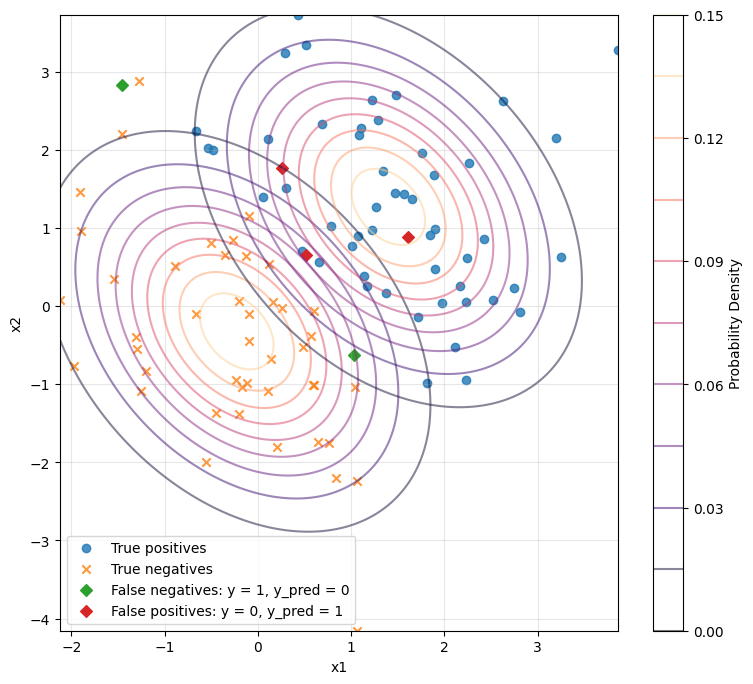

In [32]:
plt.figure(figsize = (9, 8))
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
x2 = np.linspace(X[:, 1].min(), X[:, 1].max(), 200)

X1, X2 = np.meshgrid(x1, x2)

grid = np.column_stack((X1.ravel(), X2.ravel()))

Px_y0_grid = gaussian_pdf(grid, mu0_est, Sigma_est)
Px_y1_grid = gaussian_pdf(grid, mu1_est, Sigma_est)

Z1 = Px_y0_grid.reshape(X1.shape)
Z2 = Px_y1_grid.reshape(X1.shape)

plt.contour(X1, X2, Z1, levels=10, cmap='magma', alpha=0.5)
plt.contour(X1, X2, Z2, levels=10, cmap='magma', alpha=0.5)

plt.colorbar(label = 'Probability Density')

# Plot training data
correct_ones  = (y[:,0]==1) & (y_pred[:,0]==1)
correct_zeros = (y[:,0]==0) & (y_pred[:,0]==0)
false_negatives = (y[:,0]==1) & (y_pred[:,0]==0)
false_positives = (y[:,0]==0) & (y_pred[:,0]==1)
            
plt.scatter(X[correct_ones, 0], X[correct_ones, 1], marker = 'o', label = 'True positives', alpha = 0.8)
plt.scatter(X[correct_zeros, 0], X[correct_zeros, 1], marker = 'x', label = 'True negatives', alpha = 0.8)
plt.scatter(X[false_negatives, 0], X[false_negatives, 1], marker = 'D', label = 'False negatives: y = 1, y_pred = 0')
plt.scatter(X[false_positives, 0], X[false_positives, 1], marker = 'D', label = 'False positives: y = 0, y_pred = 1')

plt.grid(alpha = 0.3)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.show()